In [6]:
import os
import glob
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# -------------------------------------------------------------
# 1. Extract Dataset from Zip
# -------------------------------------------------------------
zip_files = glob.glob("*.zip")
if not zip_files:
    raise FileNotFoundError("Error: No .zip dataset file found in current folder.")

zip_path = zip_files[0]
extract_dir = "dataset_extracted"

print(f"Extracting '{zip_path}'...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Extraction complete!")

# -------------------------------------------------------------
# 2. Load and Preprocess MRI Images (4 Classes)
# -------------------------------------------------------------
IMG_SIZE = 128
CATEGORIES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
data = []
labels = []

print("Loading MRI images...")
for root, _, files in os.walk(extract_dir):
    folder_name = os.path.basename(root).lower()
    
    # Match folder name to target class
    label_idx = None
    for idx, category in enumerate(CATEGORIES):
        if category in folder_name or category.replace('_tumor', '') in folder_name:
            label_idx = idx
            break
            
    if label_idx is not None:
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                img = cv2.imread(file_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    data.append(img)
                    labels.append(label_idx)

# Normalize pixel values (0 to 1) and one-hot encode labels
X = np.array(data, dtype="float32") / 255.0
y = to_categorical(np.array(labels), num_classes=4)

print(f"Total scans loaded: {len(X)}")

# Split dataset: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# -------------------------------------------------------------
# 3. Build Convolutional Neural Network (CNN) Model
# -------------------------------------------------------------
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------------------------------------
# 4. Train the Model
# -------------------------------------------------------------
print("\nStarting Model Training...")
history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_test, y_test), 
    epochs=12, 
    batch_size=32
)

# Save the trained model
model.save("brain_tumor_model.h5")
print("\nModel saved successfully as 'brain_tumor_model.h5'")

# -------------------------------------------------------------
# 5. Plot Training vs Validation Performance
# -------------------------------------------------------------
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

FileNotFoundError: Error: No .zip dataset file found in current folder.

Loading MRI images from folders...
Total scans loaded: 394


C:\Users\vishesh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.3683 - loss: 1.3697 - val_accuracy: 0.4557 - val_loss: 1.2621
Epoch 2/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.4571 - loss: 1.1866 - val_accuracy: 0.4684 - val_loss: 1.0858
Epoch 3/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.5714 - loss: 1.0702 - val_accuracy: 0.6076 - val_loss: 1.0130
Epoch 4/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.6476 - loss: 0.9027 - val_accuracy: 0.5316 - val_loss: 0.9444
Epoch 5/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.7238 - loss: 0.7309 - val_accuracy: 0.6329 - val_loss: 0.8181
Epoch 6/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.7714 - loss: 0.6386 - val_accuracy: 0.6456 - val_loss: 0.8581
Epoch 7/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.7937 - loss: 0.5183 - val_accuracy: 0.6203 - val_loss: 0.9413
Epoch 8/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.8889 - los


Model saved successfully as 'brain_tumor_model.h5'


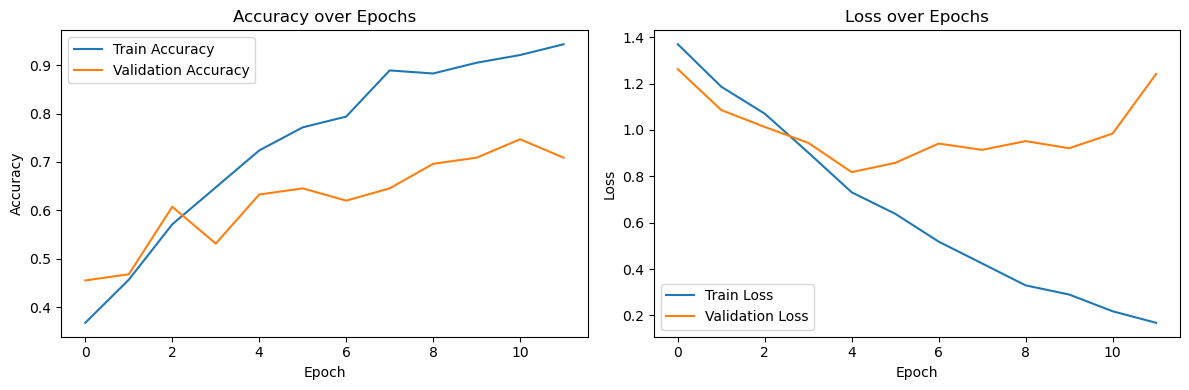

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# -------------------------------------------------------------
# 1. Load Images Directly from the 4 Local Folders
# -------------------------------------------------------------
IMG_SIZE = 128
CATEGORIES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
data = []
labels = []

print("Loading MRI images from folders...")

for label_idx, category in enumerate(CATEGORIES):
    folder_path = category
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(folder_path, file)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    data.append(img)
                    labels.append(label_idx)
    else:
        print(f"Warning: Directory '{category}' not found!")

# Normalize pixels (0 to 1) and encode labels
X = np.array(data, dtype="float32") / 255.0
y = to_categorical(np.array(labels), num_classes=4)

print(f"Total scans loaded: {len(X)}")

# Split into 80% Train and 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# -------------------------------------------------------------
# 2. Build CNN Architecture
# -------------------------------------------------------------
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------------------------------------
# 3. Train Model
# -------------------------------------------------------------
print("\nStarting model training...")
history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_test, y_test), 
    epochs=12, 
    batch_size=32
)

# Save the trained model
model.save("brain_tumor_model.h5")
print("\nModel saved successfully as 'brain_tumor_model.h5'")

# -------------------------------------------------------------
# 4. Plot Training Performance
# -------------------------------------------------------------
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
%%writefile app.py
import os
import webbrowser
from threading import Timer
import numpy as np
import cv2
from flask import Flask, request, jsonify, render_template_string
from tensorflow.keras.models import load_model

app = Flask(__name__)

# 1. Load Trained Model
MODEL_PATH = 'brain_tumor_model.h5'
model = load_model(MODEL_PATH)
CATEGORIES = ['Glioma Tumor', 'Meningioma Tumor', 'No Tumor', 'Pituitary Tumor']

# 2. Embedded HTML / CSS / JS Web Page
HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Brain Tumor Detection Portal</title>
    <style>
        * { box-sizing: border-box; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; padding: 0; }
        body { background: #f0f4f8; color: #333; display: flex; justify-content: center; align-items: center; min-height: 100vh; padding: 20px; }
        .card { background: #ffffff; width: 100%; max-width: 520px; padding: 30px; border-radius: 16px; box-shadow: 0 10px 25px rgba(0,0,0,0.08); text-align: center; }
        h1 { font-size: 24px; color: #1e293b; margin-bottom: 8px; }
        p.subtitle { font-size: 14px; color: #64748b; margin-bottom: 25px; }
        .upload-area { border: 2px dashed #cbd5e1; border-radius: 12px; padding: 25px; cursor: pointer; transition: all 0.3s ease; background: #f8fafc; }
        .upload-area:hover { border-color: #3b82f6; background: #eff6ff; }
        input[type="file"] { display: none; }
        #preview { max-width: 100%; max-height: 220px; border-radius: 8px; margin-top: 15px; display: none; object-fit: contain; }
        button { background: #2563eb; color: #fff; border: none; padding: 12px 24px; font-size: 16px; font-weight: 600; border-radius: 8px; cursor: pointer; width: 100%; margin-top: 20px; transition: background 0.3s; }
        button:hover { background: #1d4ed8; }
        button:disabled { background: #94a3b8; cursor: not-allowed; }
        #result-box { margin-top: 25px; padding: 16px; border-radius: 8px; display: none; text-align: left; }
        .success { background: #ecfdf5; border: 1px solid #10b981; color: #065f46; }
        .danger { background: #fef2f2; border: 1px solid #ef4444; color: #991b1b; }
        .res-title { font-size: 18px; font-weight: bold; margin-bottom: 6px; }
        .res-score { font-size: 14px; }
    </style>
</head>
<body>
    <div class="card">
        <h1>🧠 Brain Tumor Detector</h1>
        <p class="subtitle">Upload an MRI image to analyze tumor classification</p>
        
        <label for="imageInput" class="upload-area" id="dropArea">
            <div id="uploadText">Click or Drag & Drop MRI Image Here</div>
            <img id="preview" alt="MRI Preview">
        </label>
        <input type="file" id="imageInput" accept="image/*">
        
        <button id="predictBtn" disabled>Analyze MRI Scan</button>
        
        <div id="result-box">
            <div class="res-title" id="resTitle"></div>
            <div class="res-score" id="resScore"></div>
        </div>
    </div>

    <script>
        const imageInput = document.getElementById('imageInput');
        const preview = document.getElementById('preview');
        const uploadText = document.getElementById('uploadText');
        const predictBtn = document.getElementById('predictBtn');
        const resultBox = document.getElementById('resultBox') || document.getElementById('result-box');
        const resTitle = document.getElementById('resTitle');
        const resScore = document.getElementById('resScore');

        let selectedFile = null;

        imageInput.addEventListener('change', (e) => {
            selectedFile = e.target.files[0];
            if (selectedFile) {
                const reader = new FileReader();
                reader.onload = (event) => {
                    preview.src = event.target.result;
                    preview.style.display = 'block';
                    uploadText.style.display = 'none';
                    predictBtn.disabled = false;
                    resultBox.style.display = 'none';
                };
                reader.readAsDataURL(selectedFile);
            }
        });

        predictBtn.addEventListener('click', async () => {
            if (!selectedFile) return;
            predictBtn.innerText = 'Analyzing...';
            predictBtn.disabled = true;

            const formData = new FormData();
            formData.append('image', selectedFile);

            try {
                const response = await fetch('/predict', { method: 'POST', body: formData });
                const data = await response.json();
                
                resultBox.style.display = 'block';
                if (data.prediction === 'No Tumor') {
                    resultBox.className = 'success';
                } else {
                    resultBox.className = 'danger';
                }
                resTitle.innerText = `Result: ${data.prediction}`;
                resScore.innerText = `Confidence Score: ${data.confidence}%`;
            } catch (err) {
                alert('Error analyzing image');
            } finally {
                predictBtn.innerText = 'Analyze MRI Scan';
                predictBtn.disabled = false;
            }
        });
    </script>
</body>
</html>
"""

@app.route('/')
def home():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({'error': 'No file uploaded'}), 400
    
    file = request.files['image']
    file_bytes = np.frombuffer(file.read(), np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    
    img_resized = cv2.resize(img, (128, 128))
    img_array = np.array(img_resized, dtype="float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    preds = model.predict(img_array)
    pred_class = CATEGORIES[np.argmax(preds)]
    conf_score = round(float(np.max(preds)) * 100, 2)
    
    return jsonify({'prediction': pred_class, 'confidence': conf_score})

def open_browser():
    webbrowser.open_new("http://127.0.0.1:5000")

if __name__ == '__main__':
    Timer(1, open_browser).start()
    app.run(port=5000)

Overwriting app.py


In [ ]:
!python app.py

In [4]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. सेव किया गया मॉडल लोड करें
model = load_model('brain_tumor_model.h5')
CATEGORIES = ['Glioma Tumor', 'Meningioma Tumor', 'No Tumor', 'Pituitary Tumor']

# 2. टेस्ट करने के लिए किसी एक MRI इमेज का पाथ दें
# (उदा. 'glioma_tumor/image(1).jpg' या कोई भी इमेज फाइल का नाम)
test_image_path = 'glioma_tumor/image(1).jpg' 

# 3. इमेज प्रोसेस और प्रेडिक्शन
img = cv2.imread(test_image_path)
if img is not None:
    img_resized = cv2.resize(img, (128, 128))
    img_array = np.array(img_resized, dtype="float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)
    predicted_class = CATEGORIES[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    
    print(f"\nरिजल्ट: {predicted_class}")
    print(f"कॉन्फिडेंस स्कोर: {confidence:.2f}%")
else:
    print("इमेज फ़ाइल नहीं मिली, कृपया सही पाथ डालें!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

रिजल्ट: Glioma Tumor
कॉन्फिडेंस स्कोर: 98.47%


In [5]:
!pip install flask

In [ ]:
%%writefile app.py
import os
import webbrowser
from threading import Timer
import numpy as np
import cv2
from flask import Flask, request, jsonify, render_template_string
from tensorflow.keras.models import load_model

app = Flask(__name__)

# 1. Load Trained Model
MODEL_PATH = 'brain_tumor_model.h5'
model = load_model(MODEL_PATH)
CATEGORIES = ['Glioma Tumor', 'Meningioma Tumor', 'No Tumor', 'Pituitary Tumor']

# 2. Embedded HTML / CSS / JS Web Page
HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Brain Tumor Detection Portal</title>
    <style>
        * { box-sizing: border-box; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; padding: 0; }
        body { background: #f0f4f8; color: #333; display: flex; justify-content: center; align-items: center; min-height: 100vh; padding: 20px; }
        .card { background: #ffffff; width: 100%; max-width: 520px; padding: 30px; border-radius: 16px; box-shadow: 0 10px 25px rgba(0,0,0,0.08); text-align: center; }
        h1 { font-size: 24px; color: #1e293b; margin-bottom: 8px; }
        p.subtitle { font-size: 14px; color: #64748b; margin-bottom: 25px; }
        .upload-area { border: 2px dashed #cbd5e1; border-radius: 12px; padding: 25px; cursor: pointer; transition: all 0.3s ease; background: #f8fafc; }
        .upload-area:hover { border-color: #3b82f6; background: #eff6ff; }
        input[type="file"] { display: none; }
        #preview { max-width: 100%; max-height: 220px; border-radius: 8px; margin-top: 15px; display: none; object-fit: contain; }
        button { background: #2563eb; color: #fff; border: none; padding: 12px 24px; font-size: 16px; font-weight: 600; border-radius: 8px; cursor: pointer; width: 100%; margin-top: 20px; transition: background 0.3s; }
        button:hover { background: #1d4ed8; }
        button:disabled { background: #94a3b8; cursor: not-allowed; }
        #result-box { margin-top: 25px; padding: 16px; border-radius: 8px; display: none; text-align: left; }
        .success { background: #ecfdf5; border: 1px solid #10b981; color: #065f46; }
        .danger { background: #fef2f2; border: 1px solid #ef4444; color: #991b1b; }
        .res-title { font-size: 18px; font-weight: bold; margin-bottom: 6px; }
        .res-score { font-size: 14px; }
    </style>
</head>
<body>
    <div class="card">
        <h1>🧠 Brain Tumor Detector</h1>
        <p class="subtitle">Upload an MRI image to analyze tumor classification</p>
        
        <label for="imageInput" class="upload-area" id="dropArea">
            <div id="uploadText">Click or Drag & Drop MRI Image Here</div>
            <img id="preview" alt="MRI Preview">
        </label>
        <input type="file" id="imageInput" accept="image/*">
        
        <button id="predictBtn" disabled>Analyze MRI Scan</button>
        
        <div id="result-box">
            <div class="res-title" id="resTitle"></div>
            <div class="res-score" id="resScore"></div>
        </div>
    </div>

    <script>
        const imageInput = document.getElementById('imageInput');
        const preview = document.getElementById('preview');
        const uploadText = document.getElementById('uploadText');
        const predictBtn = document.getElementById('predictBtn');
        const resultBox = document.getElementById('resultBox') || document.getElementById('result-box');
        const resTitle = document.getElementById('resTitle');
        const resScore = document.getElementById('resScore');

        let selectedFile = null;

        imageInput.addEventListener('change', (e) => {
            selectedFile = e.target.files[0];
            if (selectedFile) {
                const reader = new FileReader();
                reader.onload = (event) => {
                    preview.src = event.target.result;
                    preview.style.display = 'block';
                    uploadText.style.display = 'none';
                    predictBtn.disabled = false;
                    resultBox.style.display = 'none';
                };
                reader.readAsDataURL(selectedFile);
            }
        });

        predictBtn.addEventListener('click', async () => {
            if (!selectedFile) return;
            predictBtn.innerText = 'Analyzing...';
            predictBtn.disabled = true;

            const formData = new FormData();
            formData.append('image', selectedFile);

            try {
                const response = await fetch('/predict', { method: 'POST', body: formData });
                const data = await response.json();
                
                resultBox.style.display = 'block';
                if (data.prediction === 'No Tumor') {
                    resultBox.className = 'success';
                } else {
                    resultBox.className = 'danger';
                }
                resTitle.innerText = `Result: ${data.prediction}`;
                resScore.innerText = `Confidence Score: ${data.confidence}%`;
            } catch (err) {
                alert('Error analyzing image');
            } finally {
                predictBtn.innerText = 'Analyze MRI Scan';
                predictBtn.disabled = false;
            }
        });
    </script>
</body>
</html>
"""

@app.route('/')
def home():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({'error': 'No file uploaded'}), 400
    
    file = request.files['image']
    file_bytes = np.frombuffer(file.read(), np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    
    img_resized = cv2.resize(img, (128, 128))
    img_array = np.array(img_resized, dtype="float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    preds = model.predict(img_array)
    pred_class = CATEGORIES[np.argmax(preds)]
    conf_score = round(float(np.max(preds)) * 100, 2)
    
    return jsonify({'prediction': pred_class, 'confidence': conf_score})

def open_browser():
    webbrowser.open_new("http://127.0.0.1:5000")

if __name__ == '__main__':
    Timer(1, open_browser).start()
    app.run(port=5000)